# Q8.
```{admonition}
:class: note
This question involves the use of simple linear regression on the `Auto` data set.

In [1]:
import pandas as pd
import numpy as np
from matplotlib.pyplot import subplots

In [154]:
import statsmodels.api as sm
from ISLP.models import ModelSpec as MS, summarize

In [152]:
from sklearn.linear_model import LinearRegression
from scipy import stats

## (a)
```{admonition}
:class: note
Use the `sm.OLS()` function to perform a simple linear regression with `mpg` as the response and `horsepower` as the predictor. Use the `summarize()` function to print the results. Comment on the output. For example:

i. Is there a relationship between the predictor and the response?

ii. How strong is the relationship between the predictor and the response?

iii. Is the relationship between the predictor and the response positive or negative?

iv. What is the predicted `mpg` associated with a `horsepower` of 98? What are the associated 95% confidence and prediction intervals?

In [ ]:
auto = pd.read_csv('../../../ALL CSV FILES - 2nd Edition/Auto.csv',na_values=['?']).dropna()

In [155]:
X = auto[['mpg']]
X = sm.add_constant(X)
y = auto['horsepower']
model_sm = sm.OLS(y,X)
results_sm = model_sm.fit()
summarize(results_sm)

,coef,std err,t,P>|t|
const,194.4756,3.873,50.211,0.0
mpg,-3.8389,0.157,-24.489,0.0


In [243]:
M = auto[['mpg']]
N = auto[['horsepower']]

model_skl = LinearRegression()
model_skl.fit(M,N)
pred = model_skl.predict(M)
resid = pred-N
n = len(resid)

rses = (np.sum(resid**2,axis=0)/(n-2)).iloc[0]

M_with_const = np.column_stack([np.ones(n),M.values])
variances = np.diag(rses*np.linalg.inv(np.matmul(M_with_const.T, M_with_const)))
se = np.sqrt(variances)

t_b0 = model_skl.intercept_[0]/se[0]
t_b1 = model_skl.coef_[0][0]/se[1]

p0 = 2*(1-stats.t.cdf(abs(t_b0),n-2))
p1 = 2*(1-stats.t.cdf(abs(t_b1),n-2))

pd.DataFrame([[model_skl.intercept_[0],se[0],t_b0,p0],[model_skl.coef_[0][0],se[1],t_b1,p1]],index=['const','mpg'],columns=['coef','std err','t','P>|t|']).round(4)

,coef,std err,t,P>|t|
const,194.4756,3.8732,50.2111,0.0
mpg,-3.8389,0.1568,-24.4891,0.0


## (b)
```{admonition}
:class: note
Plot the response and the predictor in a new set of axes ax. Use the `ax.axline()` method or the `abline()` function defined in the lab to display the least squares regression line.


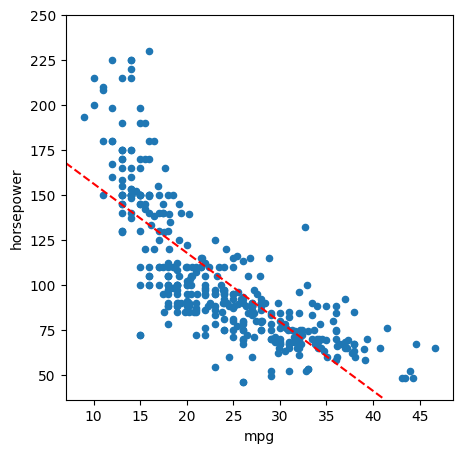

In [205]:
fig, ax = subplots(1,1,figsize=(5,5))
ax.set_xlim(X['mpg'].min()-2,X['mpg'].max()+2)
ax.set_ylim(Y['horsepower'].min()-10,Y['horsepower'].max()+20)
ax = auto.plot(x='mpg', y='horsepower', kind='scatter',ax = ax)
ax.axline((0,results_sm.params.iloc[0]),slope = results_sm.params.iloc[1],color='r',linestyle='--') ;


## (c)
```{admonition}
:class: note
Produce some of diagnostic plots of the least squares regression fit as described in the lab. Comment on any problems you see with the fit.

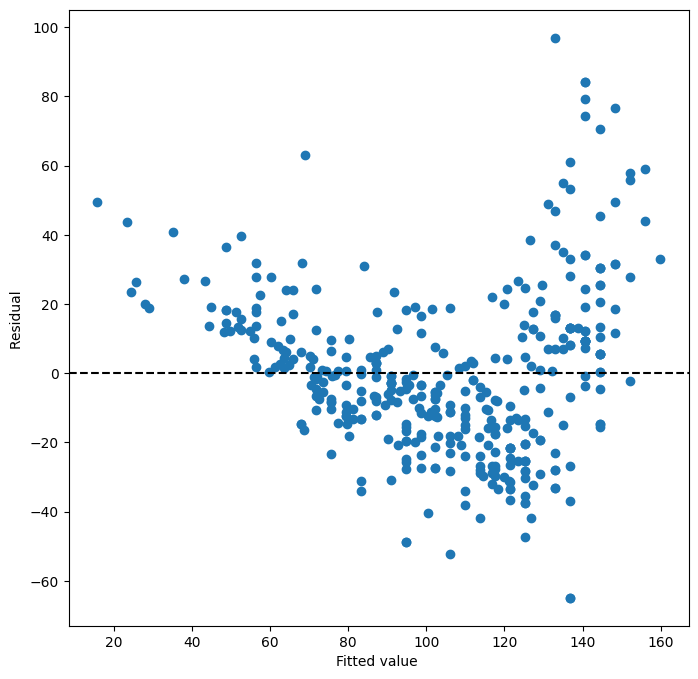

In [206]:
ax = subplots(figsize =(8 ,8))[1]
ax.scatter(results_sm.fittedvalues , results_sm.resid)
ax.set_xlabel('Fitted value ')
ax.set_ylabel('Residual ')
ax.axhline(0, c='k', ls='--');

np.int64(320)

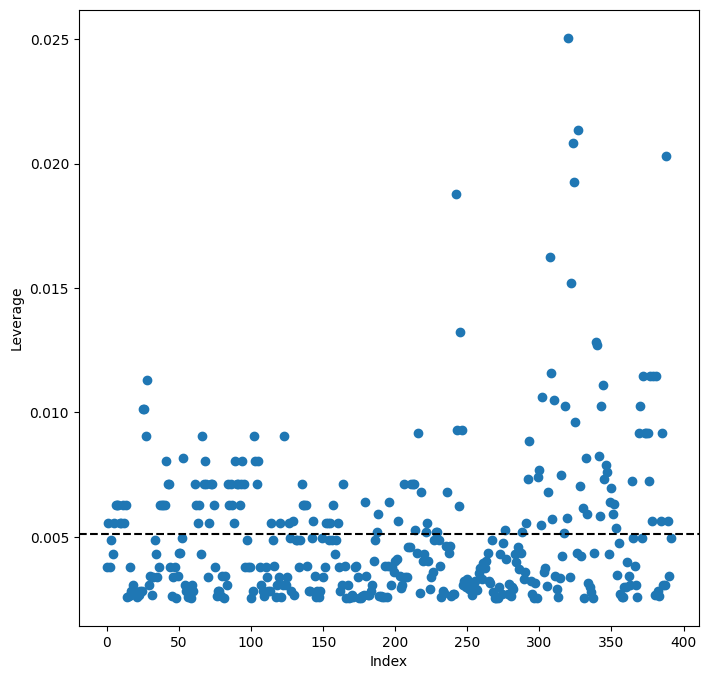

In [228]:
infl = results_sm.get_influence()
ax = subplots(figsize =(8 ,8))[1]
ax.scatter(np.arange(X.shape [0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
ax.axhline(2/n, c='k', ls='--');
np.argmax(infl.hat_matrix_diag)

np.int64(115)

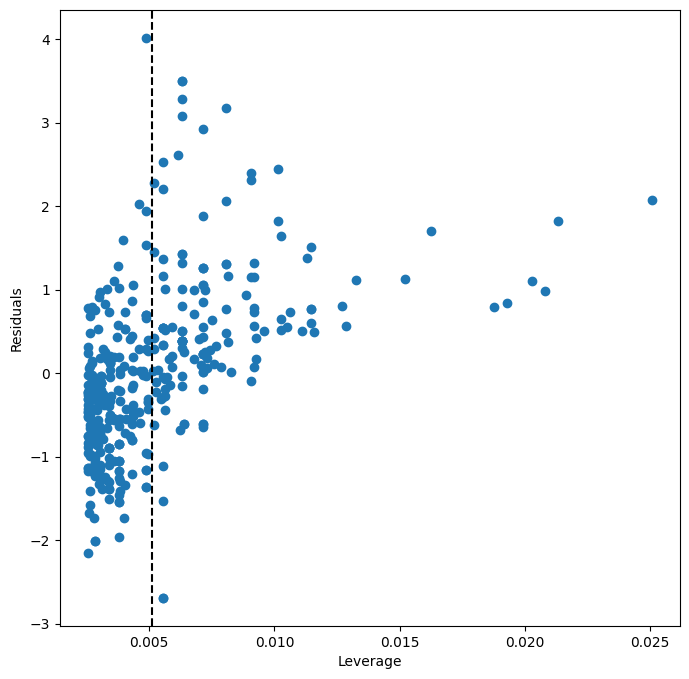

In [244]:
infl = results_sm.get_influence()
ax = subplots(figsize =(8 ,8))[1]
ax.scatter(infl.hat_matrix_diag, infl.resid_studentized_internal)
ax.axvline(2/n, c='k', ls='--');
ax.set_xlabel('Leverage')
ax.set_ylabel('Residuals') ;
np.argmax(infl.resid_studentized_internal)

In [253]:
results_sm.rsquared

np.float64(0.605948257889435)